**Task 2A**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Dataset
Loading the dirty dataset from Google Drive to start data exploration.

In [4]:
# Load the dataset (relative path so the notebook runs from the repo root)
file_path = 'data/Inconsistent_US_dataset.csv'
df = pd.read_csv(file_path)

# Quick look
df.head()

,Year,cd,State Code,State Name,Conccat,Bachelors_degree_or_higher,high_school_or_some_degree,Less_than_high_school_graduate,Less_than_$5000,$5000_to_$9999,...,Female_Wholesale_trade,Female_Retail_trade,Female_Transportation_warehousing_utilities,Female_Information,Female_Finance_insurance_realestate_rental_leasing,Female_Professional_scientific_management_administrative_waste_management_services,Female_Educationalservices_healthcare_socialassistance,Female_Arts_entertainment_recreation_accommodation_foodservices,Female_Otherservices_except_Public_administration,Female_Public_administration
0,2020,0_AK,AK,Alaska,20200_AK,121098.0,309698,33572,5949,3869,...,1192,8599,5645,1726,5924,7889,35809.0,6225,3715,14619
1,2020,0_DC,DC,District of Columbia,20200_DC,277816.0,177505,34652,14227,9856,...,453,4677,2673,5765,8757,34913,31135.0,9739,17319,29711
2,2020,0_DE,DE,Delaware,20200_DE,175338.0,351177,57053,11230,7995,...,2261,13006,4249,1722,19976,13791,58313.0,7818,4637,10870
3,2020,0_ND,ND,North Dakota,20200_ND,137958.0,303148,26631,9007,9189,...,2075,11286,2961,1451,11313,8247,50183.0,6465,4080,7483
4,2020,0_PR,PR,Puerto Rico,20200_PR,121098.0,309698,33572,178865,139225,...,5662,30674,6086,5011,26955,22692,118699.0,15752,9237,35658


### Basic Information about Dataset
Checking the number of rows, columns, and data types to understand the structure of the dataset.

In [5]:
# Checking shape of the dataset
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

if df['Year'].dtype == 'float64':
    if df['Year'].isnull().sum() > 0:
        df['Year'] = df['Year'].fillna(df['Year'].mode()[0])  # or mean()
    df['Year'] = df['Year'].astype(int)


# Checking data types
df.dtypes

Number of Rows: 887
Number of Columns: 60


,0
Year,int64
cd,object
State Code,object
State Name,object
Conccat,object
Bachelors_degree_or_higher,float64
high_school_or_some_degree,int64
Less_than_high_school_graduate,int64
Less_than_$5000,int64
$5000_to_$9999,int64


### Selecting Columns for Data Dictionary
Selecting important columns to create a data dictionary containing metadata about the dataset.

In [6]:
# Sample 10-15 columns
sample_columns = df.columns[:15]
sample_columns

Index(['Year', 'cd', 'State Code', 'State Name', 'Conccat',
       'Bachelors_degree_or_higher', 'high_school_or_some_degree',
       'Less_than_high_school_graduate', 'Less_than_$5000', '$5000_to_$9999',
       '$10000_to_$14999', '$15000_to_$19999', '$20000_to_$24999',
       '$25000_to_$34999', '$35000_to_$49999'],
      dtype='object')

### Data Dictionary

In [7]:
# Only selecting your 15 columns
selected_cols = [
    'Year', 'cd', 'State Code', 'State Name', 'Conccat',
    'Bachelors_degree_or_higher', 'high_school_or_some_degree','Less_than_$5000',
    '$150000_or_more', 'Total_Agriculture_forestry_fishing_hunting_mining', 'Total_Transportation_warehousing_utilities',
    'Total_Finance_insurance_realestate_rental_leasing', 'Total_Professional_scientific_management_administrative_waste_management_services',
    'Total_Educationalservices_healthcare_socialassistance', 'Total_Arts_entertainment_recreation_accommodation_foodservices'
    'Total_Otherservices_except_Public_administration', 'Total_Public_administration'
]
# Filter only columns that exist in the DataFrame
existing_cols = [col for col in selected_cols if col in df.columns]

# Create Data Dictionary
data_dictionary = pd.DataFrame({
    'Column Name': existing_cols,
    'Data Type': df[existing_cols].dtypes.astype(str).values,
    'Sample Value': df[existing_cols].iloc[0].values
})

# Format Mapping
format_mapping = {
    'int64': 'Integer',
    'float64': 'Decimal',
    'object': 'Text'
}

# Add Format Column
data_dictionary['Format'] = data_dictionary['Data Type'].map(format_mapping)

# Add Field Size
data_dictionary['Field Size'] = data_dictionary['Sample Value'].astype(str).apply(len)

# Add Keywords
keyword_mapping = {
    'Year': 'Time',
    'cd': 'Location',
    'State Code': 'Location',
    'State Name': 'Location',
    'Conccat': 'ID',

    'Bachelors_degree_or_higher': 'Education',
    'high_school_or_some_degree': 'Education',

    'Less_than_$5000': 'Income',
    '$150000_or_more': 'Income',

    'Total_Agriculture_forestry_fishing_hunting_mining': 'Industry',
    'Total_Transportation_warehousing_utilities': 'Industry',
    'Total_Finance_insurance_realestate_rental_leasing': 'Industry',
    'Total_Professional_scientific_management_administrative_waste_management_services': 'Industry',
    'Total_Educationalservices_healthcare_socialassistance': 'Industry',
    'Total_Arts_entertainment_recreation_accommodation_foodservices': 'Industry',
    'Total_Otherservices_except_Public_administration': 'Industry',
    'Total_Public_administration': 'Industry'
}

data_dictionary['Keywords'] = data_dictionary['Column Name'].map(keyword_mapping)

# Add Descriptions
description_mapping = {
    'Year': 'The year the data was recorded (typically Census year).',
    'cd': 'Census code representing the state and year combination.',
    'State Code': 'Abbreviated state code (e.g., CA for California).',
    'State Name': 'Full name of the U.S. state.',
    'Conccat': 'Concatenated key field (State + Year).',

    'Bachelors_degree_or_higher': 'Population with a bachelor\'s degree or higher.',
    'high_school_or_some_degree': 'Population with at least high school or some college.',

    'Less_than_$5000': 'Individuals with income less than $5,000.',
    '$150000_or_more': 'Individuals with income greater than or equal to $150,000.',

    'Total_Agriculture_forestry_fishing_hunting_mining': 'Total employment in agriculture, forestry, fishing, hunting, and mining industries.',
    'Total_Transportation_warehousing_utilities': 'Total employment in transportation, warehousing, and utilities industries.',
    'Total_Finance_insurance_realestate_rental_leasing': 'Total employment in finance, insurance, real estate, rental, and leasing industries.',
    'Total_Professional_scientific_management_administrative_waste_management_services': 'Total employment in professional, scientific, and administrative waste management services.',
    'Total_Educationalservices_healthcare_socialassistance': 'Total employment in education, healthcare, and social assistance services.',
    'Total_Arts_entertainment_recreation_accommodation_foodservices': 'Total employment in arts, entertainment, recreation, accommodation, and food services.',
    'Total_Otherservices_except_Public_administration': 'Total employment in other services excluding public administration.',
    'Total_Public_administration': 'Total employment in public administration.'
}

data_dictionary['Description'] = data_dictionary['Column Name'].map(description_mapping)


# Final Output
data_dictionary

,Column Name,Data Type,Sample Value,Format,Field Size,Keywords,Description
0,Year,int64,2020,Integer,4,Time,The year the data was recorded (typically Cens...
1,cd,object,0_AK,Text,4,Location,Census code representing the state and year co...
2,State Code,object,AK,Text,2,Location,"Abbreviated state code (e.g., CA for California)."
3,State Name,object,Alaska,Text,6,Location,Full name of the U.S. state.
4,Conccat,object,20200_AK,Text,8,ID,Concatenated key field (State + Year).
5,Bachelors_degree_or_higher,float64,121098.0,Decimal,8,Education,Population with a bachelor's degree or higher.
6,high_school_or_some_degree,int64,309698,Integer,6,Education,Population with at least high school or some c...
7,Less_than_$5000,int64,5949,Integer,4,Income,"Individuals with income less than $5,000."
8,$150000_or_more,int64,47139,Integer,5,Income,Individuals with income greater than or equal ...
9,Total_Agriculture_forestry_fishing_hunting_mining,int64,9356,Integer,4,Industry,"Total employment in agriculture, forestry, fis..."


In [8]:
# Ensuring all the numerical Columns are Integer Values.
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Convert them to Integer)
df[numeric_cols] = df[numeric_cols].astype('Int64')

In [9]:
# Checking the columns
print(df.dtypes)

Year                                                                                   Int64
cd                                                                                    object
State Code                                                                            object
State Name                                                                            object
Conccat                                                                               object
Bachelors_degree_or_higher                                                             Int64
high_school_or_some_degree                                                             Int64
Less_than_high_school_graduate                                                         Int64
Less_than_$5000                                                                        Int64
$5000_to_$9999                                                                         Int64
$10000_to_$14999                                                      

### Descriptive Statistics
Generating basic descriptive statistics to understand the central tendency, spread, and shape of the dataset’s distribution.

In [10]:
# Descriptive statistics for numeric columns
df.describe()

,Year,Bachelors_degree_or_higher,high_school_or_some_degree,Less_than_high_school_graduate,Less_than_$5000,$5000_to_$9999,$10000_to_$14999,$15000_to_$19999,$20000_to_$24999,$25000_to_$34999,...,Female_Wholesale_trade,Female_Retail_trade,Female_Transportation_warehousing_utilities,Female_Information,Female_Finance_insurance_realestate_rental_leasing,Female_Professional_scientific_management_administrative_waste_management_services,Female_Educationalservices_healthcare_socialassistance,Female_Arts_entertainment_recreation_accommodation_foodservices,Female_Otherservices_except_Public_administration,Female_Public_administration
count,887.0,840.0,887.0,887.0,887.0,887.0,840.0,887.0,887.0,887.0,...,887.0,887.0,887.0,887.0,887.0,887.0,857.0,887.0,887.0,887.0
mean,2020.499436,145151.992857,269343.59301,49396.314543,9105.121759,7570.491545,11676.108333,11357.590755,11959.94363,23993.547914,...,2093.314543,10155.306652,3503.323563,2020.258174,10295.456595,12382.273957,40802.905484,7161.382187,4554.92221,6519.155581
std,0.500282,80653.993091,108925.100091,30542.117827,9061.474225,7352.043348,8401.279787,7477.220286,6737.748816,11927.596032,...,1212.596174,4244.399601,2070.72784,1786.886729,5209.490767,7658.775594,16127.855959,3979.579528,2292.034518,4336.849203
min,2020.0,2872.0,12603.0,2072.0,64.0,267.0,207.0,161.0,227.0,619.0,...,72.0,443.0,81.0,0.0,525.0,272.0,1369.0,350.0,174.0,160.0
25%,2020.0,91828.75,198717.0,31724.5,5611.5,4558.5,7473.25,7131.0,7830.5,16163.5,...,1289.5,7590.5,2224.0,1097.0,6741.0,7292.0,30462.0,4971.5,3079.5,3993.5
50%,2020.0,125764.0,266605.0,43688.0,8136.0,6554.0,10782.5,10805.0,11572.0,23561.0,...,1806.0,9723.0,3041.0,1616.0,9297.0,10439.0,40613.0,6364.0,4249.0,5503.0
75%,2021.0,180791.75,340419.5,58328.0,11039.0,9159.5,14581.25,14612.5,15415.5,31280.0,...,2622.5,12571.5,4209.5,2344.5,12951.5,15165.0,51871.0,8618.0,5567.5,7885.5
max,2021.0,561182.0,1191468.0,257422.0,178865.0,139225.0,140660.0,122422.0,98327.0,151568.0,...,8541.0,32623.0,16699.0,19425.0,29256.0,47166.0,120213.0,49770.0,17319.0,37435.0


In [11]:
# Distinct counts for each column
df.nunique()

,0
Year,2
cd,437
State Code,83
State Name,83
Conccat,874
Bachelors_degree_or_higher,838
high_school_or_some_degree,871
Less_than_high_school_graduate,869
Less_than_$5000,844
$5000_to_$9999,853


### Frequency Distribution of Categorical Variables

In [12]:
# Checking categorical columns
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['cd', 'State Code', 'State Name', 'Conccat'], dtype='object')

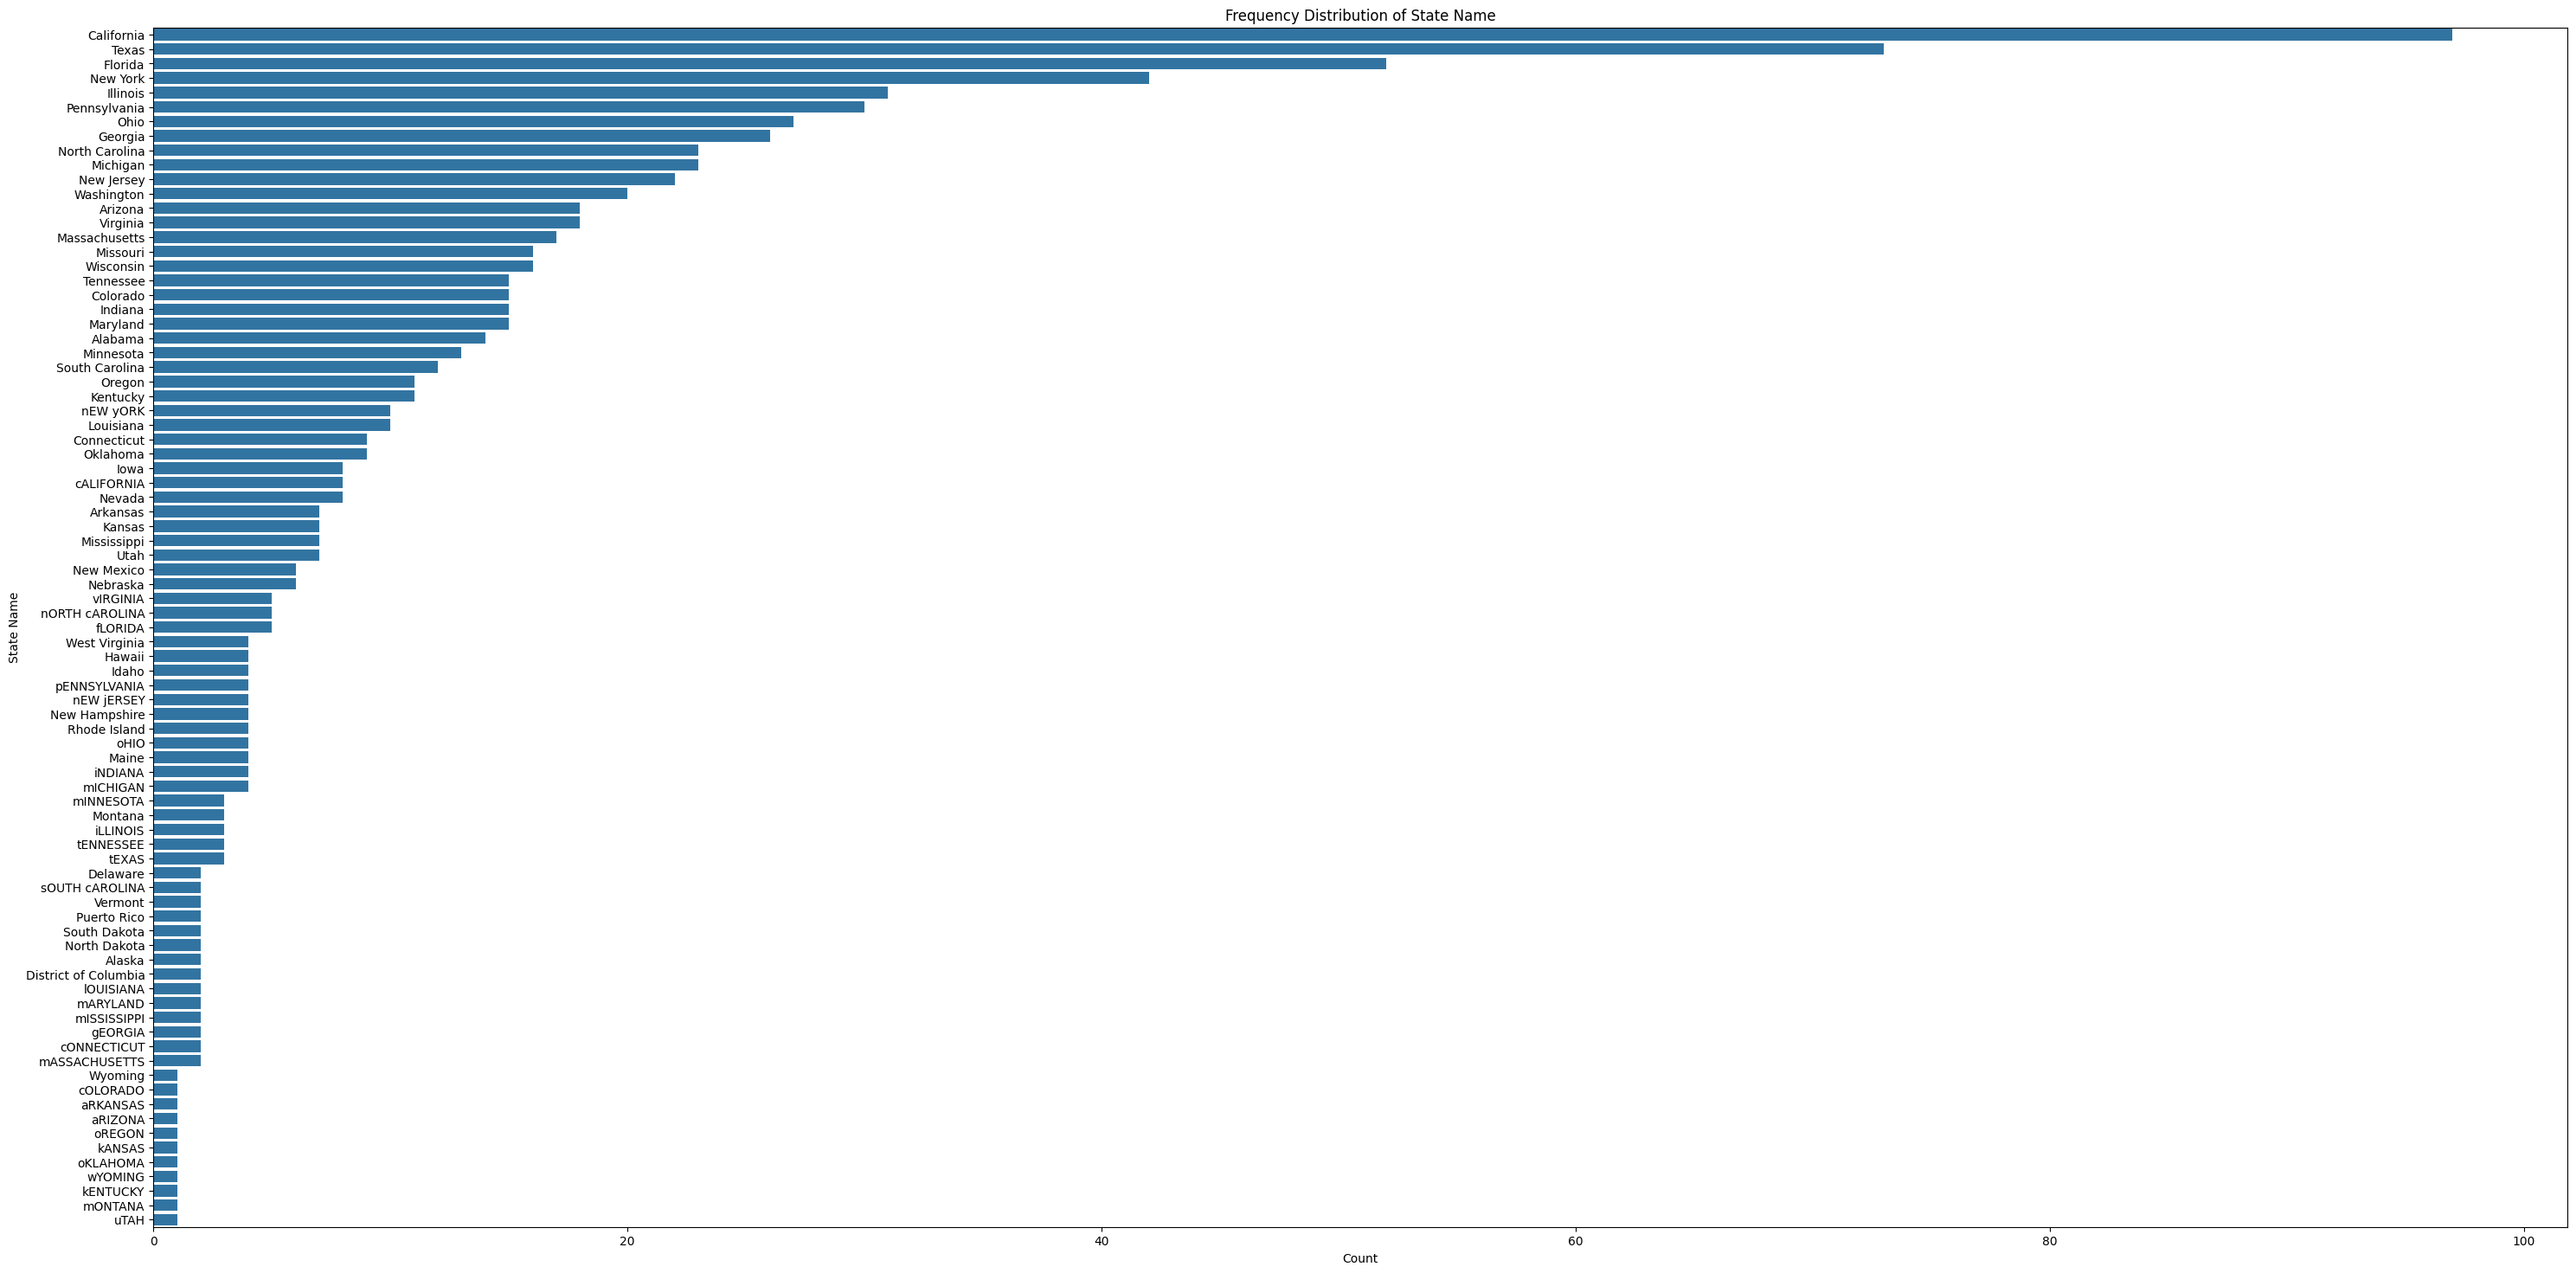

In [13]:
# Frequency Plot for 'State Name'
plt.figure(figsize=(36,18))
sns.countplot(y=df['State Name'], order=df['State Name'].value_counts().index)
plt.title('Frequency Distribution of State Name')
plt.xlabel('Count')
plt.ylabel('State Name')
plt.show()

### Missing Value Identification
Finding missing values across columns and visualizing the missingness pattern using a heatmap.

In [14]:
# Missing values count and percentage
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

# Create a table
missing_table = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

# Filter and sort
missing_table = missing_table[missing_table['Missing Values'] > 0]
missing_table = missing_table.sort_values(by='Percentage (%)', ascending=False)

# Display the table
import pandas as pd
import matplotlib.pyplot as plt
missing_table

,Missing Values,Percentage (%)
Bachelors_degree_or_higher,47,5.298760
$10000_to_$14999,47,5.298760
$50000_to_$74999,47,5.298760
Total_Construction,46,5.186020
Total_Finance_insurance_realestate_rental_leasing,30,3.382187
Male_Construction,30,3.382187
Male_Finance_insurance_realestate_rental_leasing,30,3.382187
Female_Educationalservices_healthcare_socialassistance,30,3.382187


Heatmap for Missing Values

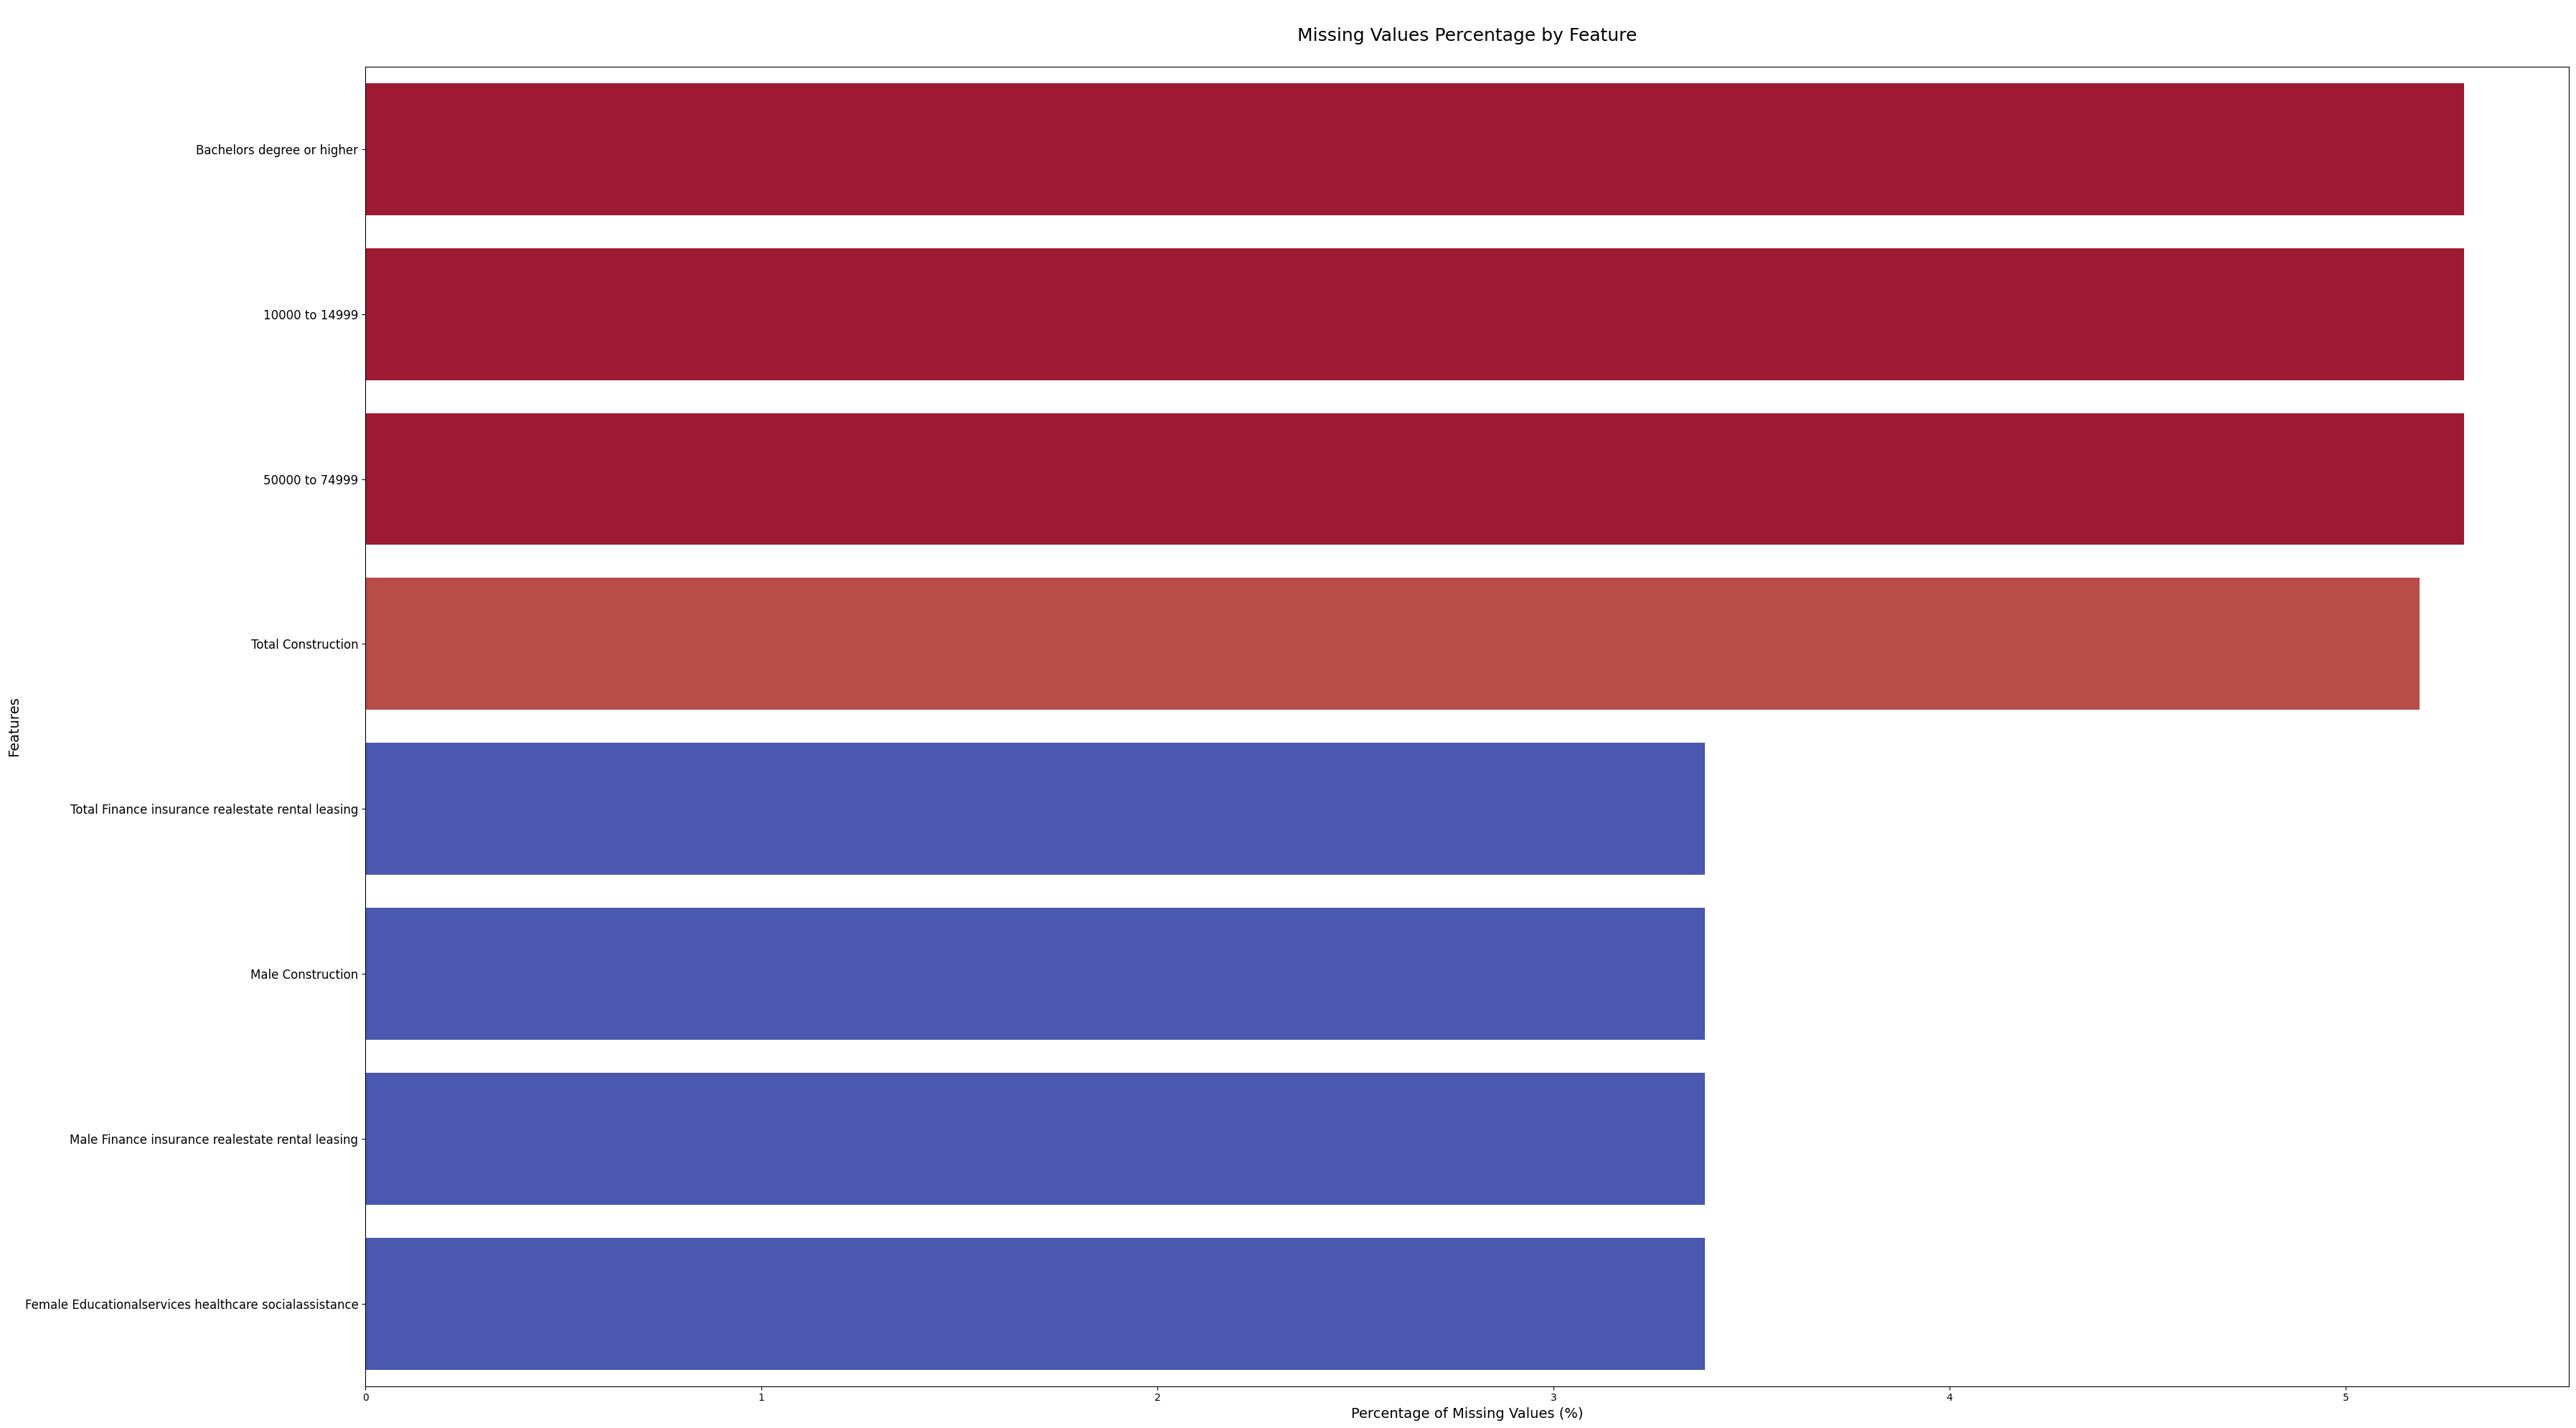

In [15]:
# Barplot of missing value percentages with fixed label handling
plt.figure(figsize=(36, 20))

# Create barplot
ax = sns.barplot(
    x='Percentage (%)',
    y=missing_table.index,
    data=missing_table.reset_index(),  # Ensure it's compatible
    palette='coolwarm',
    hue='Percentage (%)',  # Satisfies future hue warning
    dodge=False,
    legend=False
)

# Fix label display: Replace _ and $ for clarity
clean_labels = [label.get_text().replace('_', ' ').replace('$', '') for label in ax.get_yticklabels()]
ax.set_yticks(range(len(clean_labels)))
ax.set_yticklabels(clean_labels, fontsize=12)

# Titles and labels
ax.set_title('\nMissing Values Percentage by Feature\n', fontsize=18)
ax.set_xlabel('Percentage of Missing Values (%)', fontsize=14)
ax.set_ylabel('Features', fontsize=14)

plt.tight_layout()
plt.show()

Handling Missing Values

In [16]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64']).columns

# Replace missing values with the rounded mean (integer)
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        mean_val = round(df[col].mean())
        df[col] = df[col].fillna(int(mean_val))

# Step 5: Confirm missing values are handled
print("\nMissing values after full imputation:", df.isnull().sum().sum())


Missing values after full imputation: 0


### Outlier Detection

Identifing outliers using the following method:
- Statistical Detection using the IQR (Interquartile Range) Method

Outliers are extreme values that can distort statistical analysis and visualizations.

Detecting and treating outliers ensures the reliability and accuracy of subsequent data analyses.

In [17]:
# Remove all '$' signs from all column names
df.columns = df.columns.str.replace('$', '', regex=False)

In [18]:
numeric_cols = df.select_dtypes(include='Int64').columns

In [19]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = {
        'Outlier Count': outliers.shape[0],
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    }

# Convert to DataFrame for display
outlier_df = pd.DataFrame(outlier_summary).T.sort_values(by='Outlier Count', ascending=False)
# Show top 10 columns with most outliers
outlier_df.head(10)

,Outlier Count,Lower Bound,Upper Bound
Male_Agriculture_forestry_fishing_hunting_mining,75.0,-5214.75,10559.25
Total_Agriculture_forestry_fishing_hunting_mining,70.0,-6128.75,12721.25
Female_Agriculture_forestry_fishing_hunting_mining,63.0,-825.75,1960.25
150000_or_more,63.0,-22477.75,104572.25
Total_Information,55.0,-1999.75,11374.25
Female_Information,54.0,-774.25,4215.75
Total_Professional_scientific_management_administrative_waste_management_services,52.0,-12101.50,70342.50
Male_Information,51.0,-1558.00,7514.00
Female_Professional_scientific_management_administrative_waste_management_services,51.0,-4517.50,26974.50
Less_than_high_school_graduate,50.0,-8180.75,98233.25


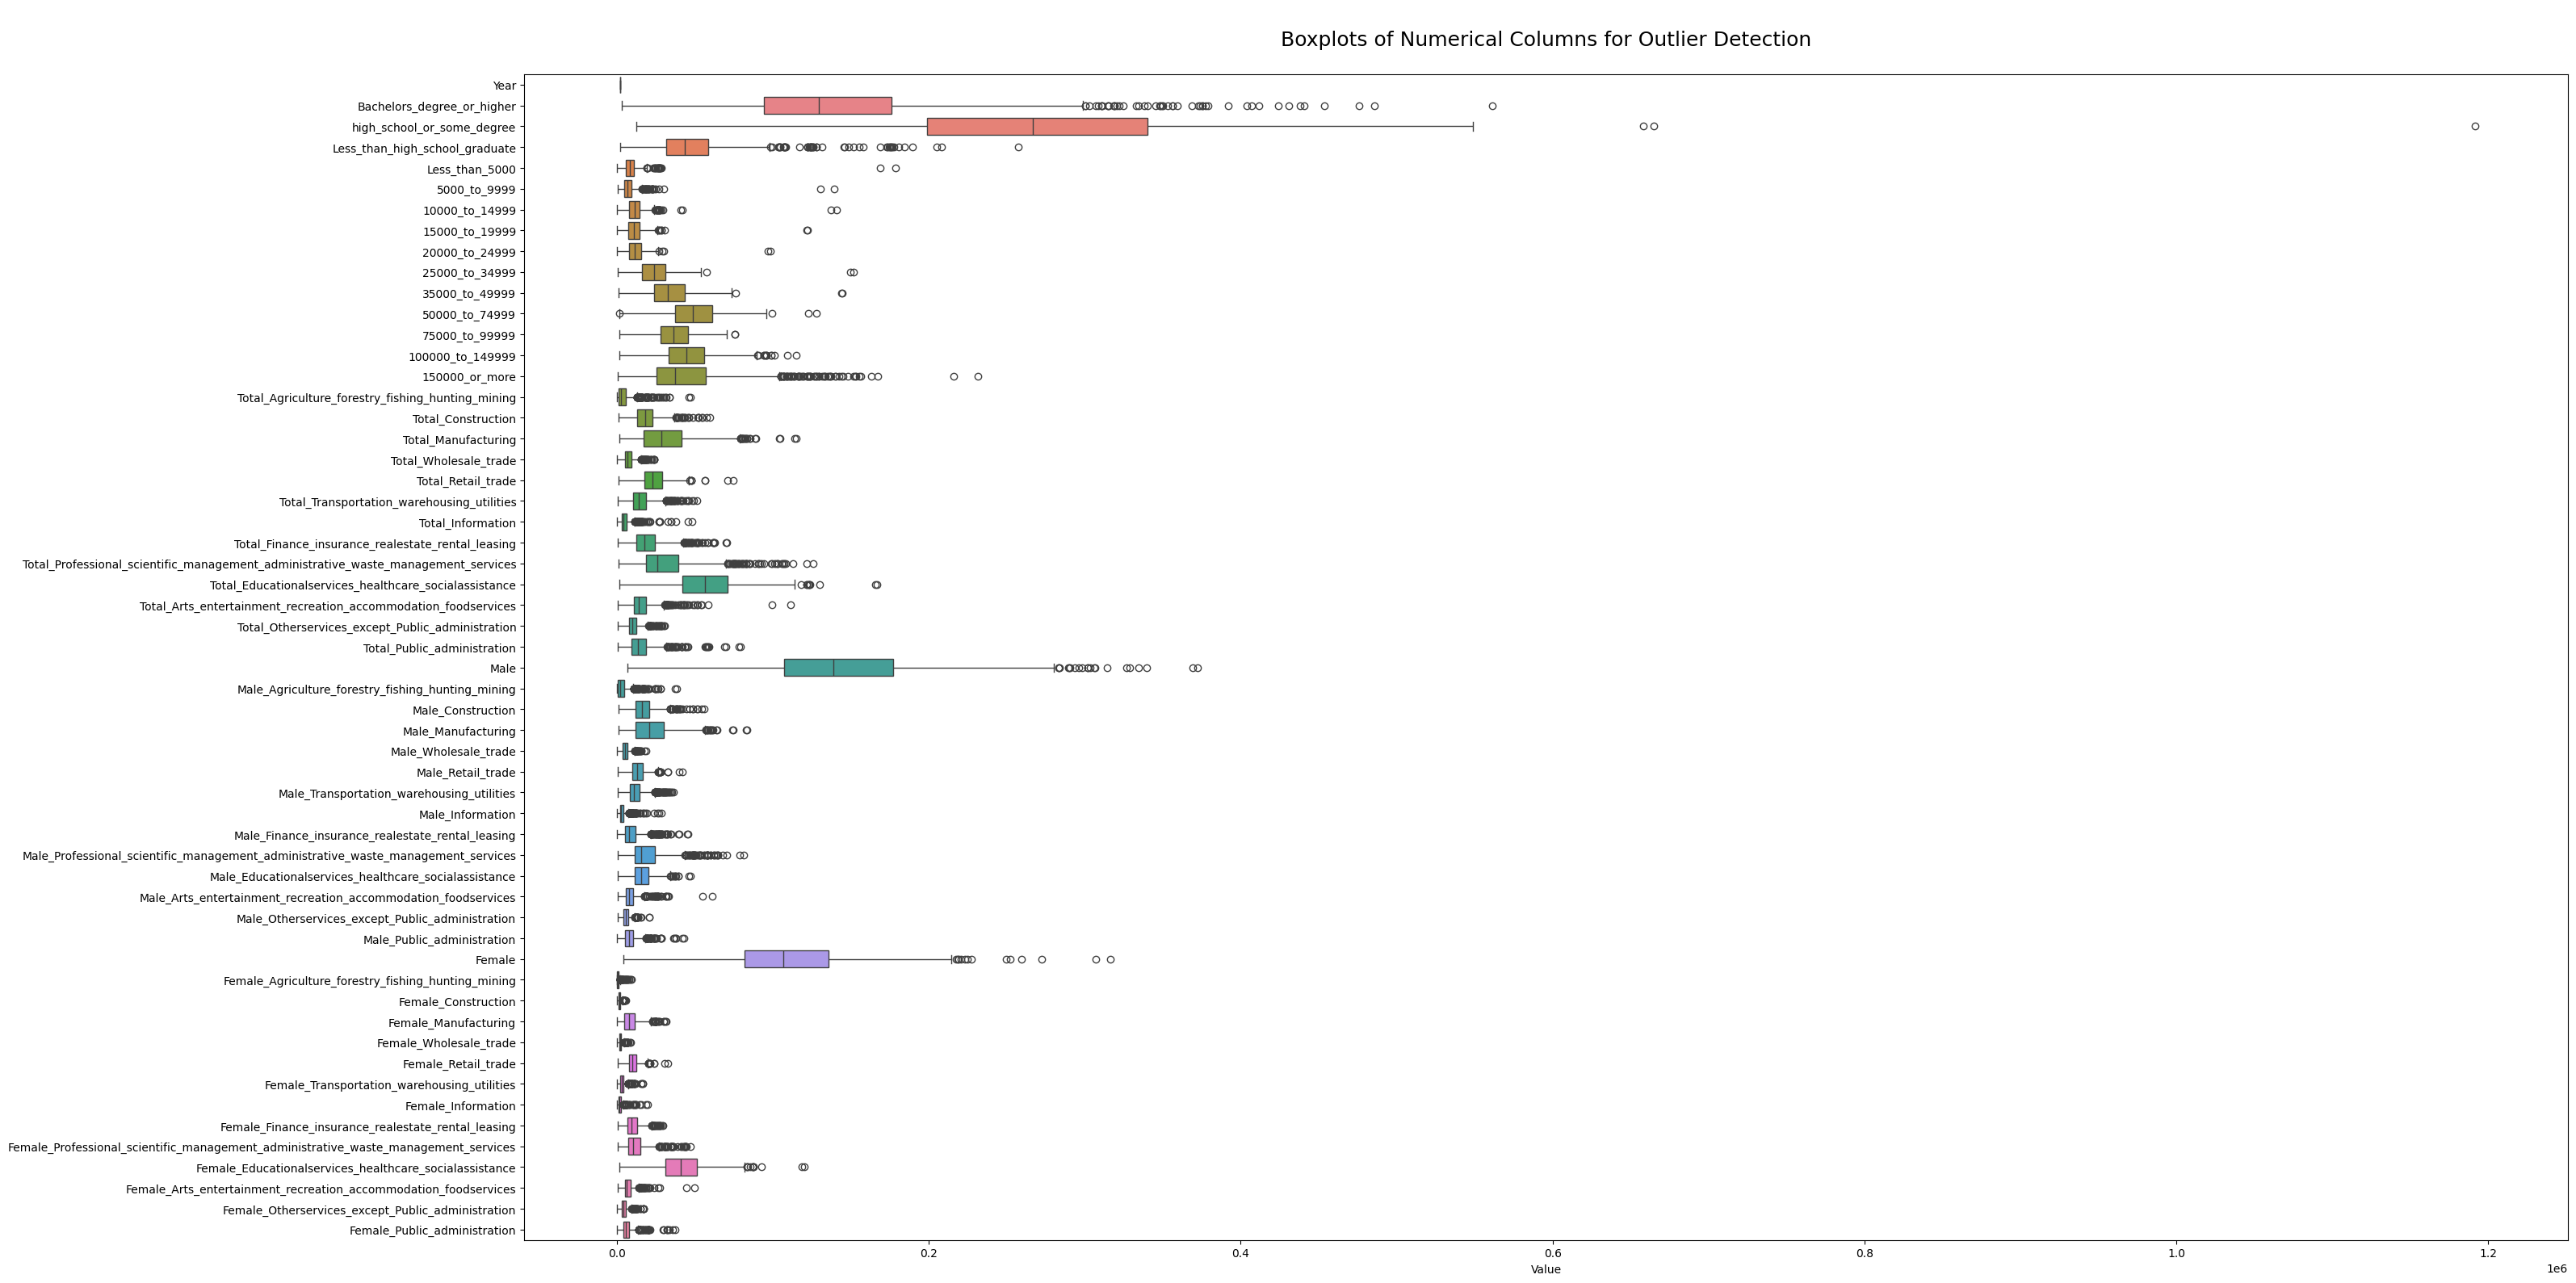

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64']).columns

# Set figure size
plt.figure(figsize=(32, 16))

# Create boxplot
sns.boxplot(data=df[numeric_cols], orient='h')

# Title and styling
plt.title('\nBoxplots of Numerical Columns for Outlier Detection\n', fontsize=18)
plt.xlabel('Value')
plt.tight_layout()
plt.show()

The outliers were detected using the IQR method.

Handle Outliers

All numeric column outliers capped using IQR and cast to integers.


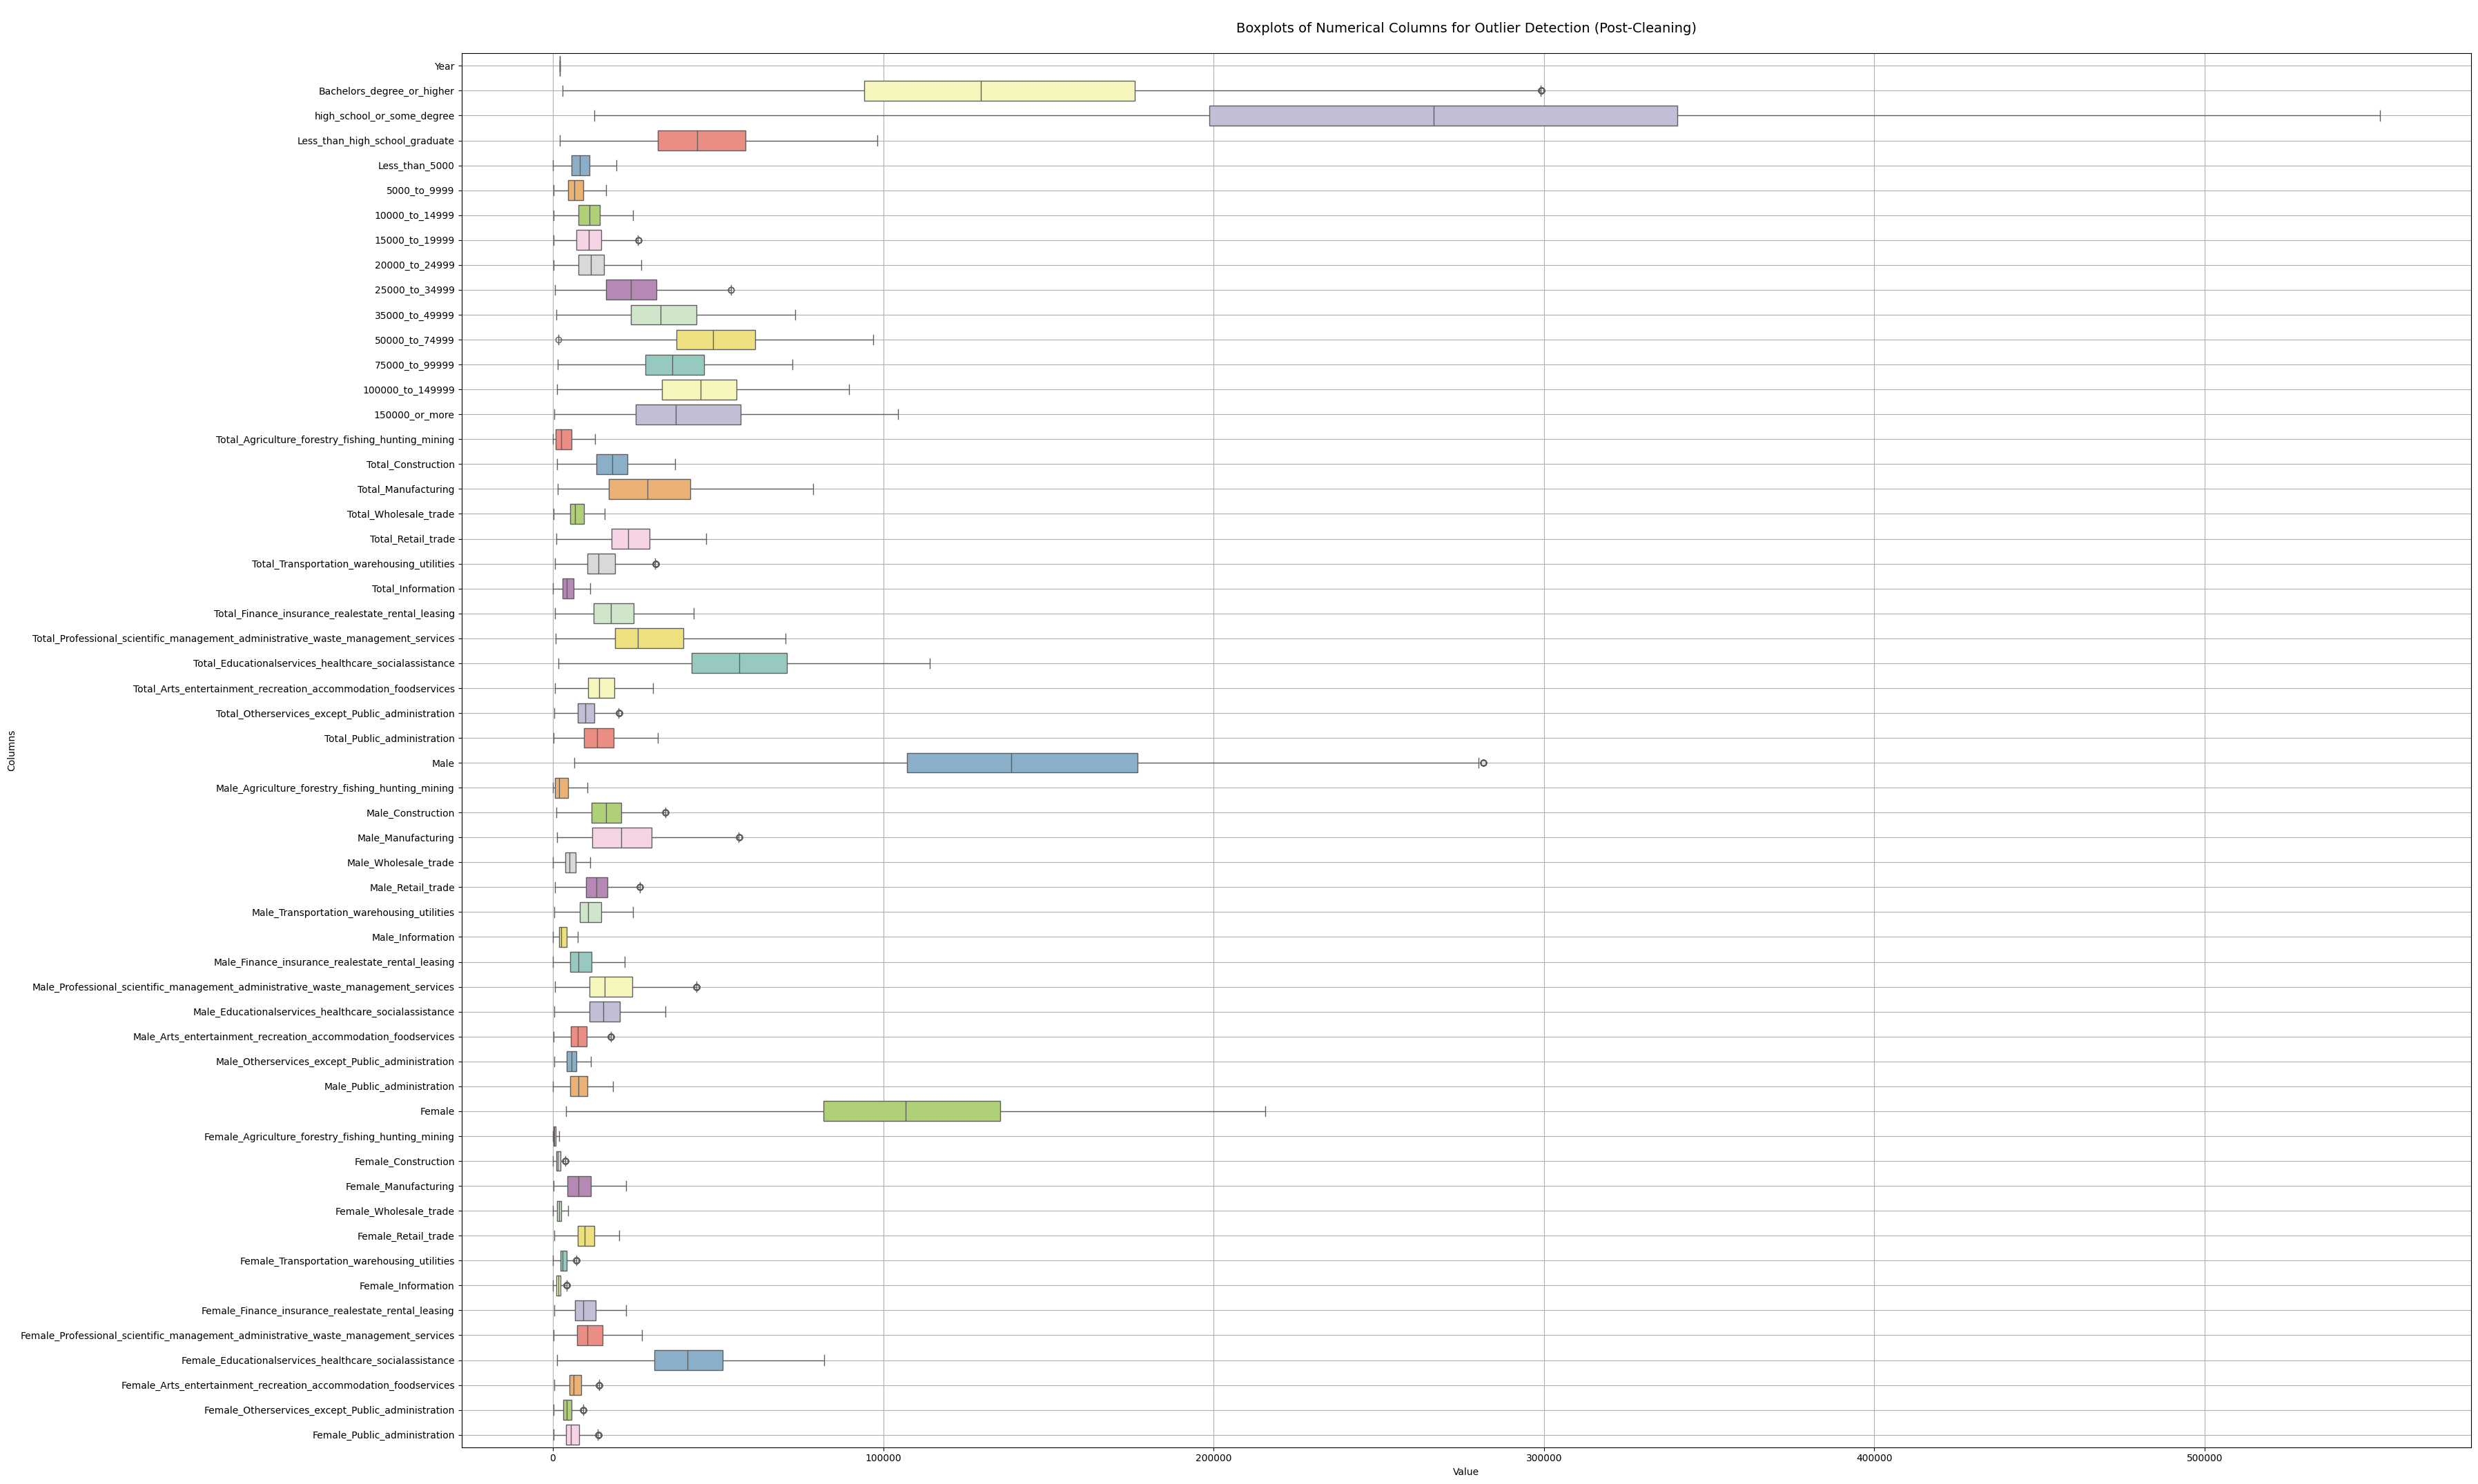

In [21]:
# Handle outliers for all numeric columns using IQR method
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    # Convert column to float temporarily to allow float ops
    temp_col = df[col].astype(float)

    # IQR calculation
    Q1 = temp_col.quantile(0.25)
    Q3 = temp_col.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping and casting back to int
    capped_values = temp_col.clip(lower=lower_bound, upper=upper_bound).round().astype(int)
    df[col] = capped_values  # assign after cleaning

print("All numeric column outliers capped using IQR and cast to integers.")

# Visualization after handling the outliers
plt.figure(figsize=(36, 21.6))
sns.boxplot(data=df[numeric_cols], orient='h', palette="Set3")
plt.title("\nBoxplots of Numerical Columns for Outlier Detection (Post-Cleaning)\n", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Columns")
plt.grid(True)
plt.tight_layout()
plt.show()

### Anomaly and Quality Checks

Checking for Text Inconsistencies

In [22]:
# Show all current column names
columns_df = pd.DataFrame(df.columns, columns=['Column Name'])
print(columns_df)

                                          Column Name
0                                                Year
1                                                  cd
2                                          State Code
3                                          State Name
4                                             Conccat
5                          Bachelors_degree_or_higher
6                          high_school_or_some_degree
7                      Less_than_high_school_graduate
8                                      Less_than_5000
9                                        5000_to_9999
10                                     10000_to_14999
11                                     15000_to_19999
12                                     20000_to_24999
13                                     25000_to_34999
14                                     35000_to_49999
15                                     50000_to_74999
16                                     75000_to_99999
17                          

In [23]:
# Checking for Text Consistencies
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Collect inconsistencies
text_inconsistencies = {}

for col in categorical_cols:
    original_values = set(df[col].dropna().unique())
    normalized_values = set(df[col].dropna().str.strip().str.lower().unique())

    if len(original_values) != len(normalized_values):
        text_inconsistencies[col] = {
            "original": original_values,
            "normalized": normalized_values
        }


In [24]:
text_inconsistencies.keys()

dict_keys(['State Code', 'State Name'])

In [25]:
# Cleaning text inconsistencies
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Convert specific columns to desired case formats
df['cd'] = df['cd'].str.upper()
df['State Code'] = df['State Code'].str.upper()
df['State Name'] = df['State Name'].str.title()

Text Consistency Check

Performed text consistency checks on the categorical columns to identify any leading/trailing spaces and to standardize the casing (title case).
Applied cleaning technique to effectively change the values in 'State Code' and 'State Name' Columns.

**Task 2B**

Dropping the redundant columns to make the dataset more efficient for further analysis.

In [26]:
columns_to_drop = [
    'Conccat',
    'Total_Agriculture_forestry_fishing_hunting_mining',
    'Total_Construction',
    'Total_Wholesale_trade',
    'Total_Transportation_warehousing_utilities',
    'Total_Information',
    'Total_Professional_scientific_management_administrative_waste_management_services',
    'Total_Otherservices_except_Public_administration',
    'Total_Public_administration',
    'Male_Agriculture_forestry_fishing_hunting_mining',
    'Male_Construction',
    'Male_Wholesale_trade',
    'Male_Transportation_warehousing_utilities',
    'Male_Information',
    'Male_Professional_scientific_management_administrative_waste_management_services',
    'Male_Otherservices_except_Public_administration',
    'Male_Public_administration',
    'Female_Agriculture_forestry_fishing_hunting_mining',
    'Female_Construction',
    'Female_Wholesale_trade',
    'Female_Transportation_warehousing_utilities',
    'Female_Information',
    'Female_Professional_scientific_management_administrative_waste_management_services',
    'Female_Otherservices_except_Public_administration',
    'Female_Public_administration'
]

df.drop(columns=columns_to_drop, inplace=True)
print(f"Dropped {len(columns_to_drop)} redundant columns.")

Dropped 25 redundant columns.


### Check and Remove Duplicates

Duplicate rows can inflate the results of statistical analysis and lead to biased insights.  
Thus, first check for any duplicate entries in the dataset and remove them.

In [27]:
# Check number of duplicates
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Remove duplicates
df = df.drop_duplicates()

# Confirm removal
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate rows: 13
Shape after removing duplicates: (874, 35)


A total of **13 duplicate rows** were found and successfully removed.  
The dataset size reduced from **(917, 58)** to **(874, 48)** after duplicate removal.

### Format Columns

Combine the Finance Columns to broad categories

In [28]:
# Combine income columns into broader categories
df['Income_Under_5K'] = df['Less_than_5000']

df['Income_5K_to_25K'] = df[['5000_to_9999', '10000_to_14999', '15000_to_19999']].sum(axis=1)

df['Income_25K_to_75K'] = df[['20000_to_24999', '25000_to_34999', '35000_to_49999']].sum(axis=1)

df['Income_75K_to_150K'] = df[['50000_to_74999', '75000_to_99999', '100000_to_149999']].sum(axis=1)

df['Income_Above_150K'] = df['150000_or_more']

# Drop the old income columns
columns_to_drop = [
    'Less_than_5000', '5000_to_9999', '10000_to_14999', '15000_to_19999',
    '20000_to_24999', '25000_to_34999', '35000_to_49999',
    '50000_to_74999', '75000_to_99999', '100000_to_149999',
    '150000_or_more'
]
df.drop(columns=columns_to_drop, inplace=True)

<ipython-input-28-63780fa772e3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income_Under_5K'] = df['Less_than_5000']
<ipython-input-28-63780fa772e3>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income_5K_to_25K'] = df[['5000_to_9999', '10000_to_14999', '15000_to_19999']].sum(axis=1)
<ipython-input-28-63780fa772e3>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

Rename Lengthy Column Names

In [29]:
#Shorten Long Column Names

# Define the new column names
rename_cols = {
    'Bachelors_degree_or_higher':                                      'Bachelors_Higher',
    'high_school_or_some_degree':                                      'HighSchool_or_SomeCollege',
    'Less_than_high_school_graduate':                                  'LessThan_HighSchool',
    'Total_Transportation_warehousing_utilities':                      'Total_Transport',
    'Total_Finance_insurance_realestate_rental_leasing':               'Total_Finance',
    'Total_Educationalservices_healthcare_socialassistance':           'Total_Education',
    'Total_Arts_entertainment_recreation_accommodation_foodservices':  'Total_Arts',
    'Male_Transportation_warehousing_utilities':                       'Male_Transport',
    'Male_Finance_insurance_realestate_rental_leasing':                'Male_Finance',
    'Male_Educationalservices_healthcare_socialassistance':            'Male_Education',
    'Male_Arts_entertainment_recreation_accommodation_foodservices':   'Male_Arts',
    'Female_Transportation_warehousing_utilities':                     'Female_Transport',
    'Female_Finance_insurance_realestate_rental_leasing':              'Female_Finance',
    'Female_Educationalservices_healthcare_socialassistance':          'Female_Education',
    'Female_Arts_entertainment_recreation_accommodation_foodservices': 'Female_Arts'
}


# Apply the renaming in one go
df.rename(columns=rename_cols, inplace=True)

# Confirm
print("Columns after renaming:", df.columns.tolist())

Columns after renaming: ['Year', 'cd', 'State Code', 'State Name', 'Bachelors_Higher', 'HighSchool_or_SomeCollege', 'LessThan_HighSchool', 'Total_Manufacturing', 'Total_Retail_trade', 'Total_Finance', 'Total_Education', 'Total_Arts', 'Male', 'Male_Manufacturing', 'Male_Retail_trade', 'Male_Finance', 'Male_Education', 'Male_Arts', 'Female', 'Female_Manufacturing', 'Female_Retail_trade', 'Female_Finance', 'Female_Education', 'Female_Arts', 'Income_Under_5K', 'Income_5K_to_25K', 'Income_25K_to_75K', 'Income_75K_to_150K', 'Income_Above_150K']


<ipython-input-29-4f66042fee62>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns=rename_cols, inplace=True)


### Save Cleaned Dataset

In [ ]:
# Save the fully cleaned dataset
df.to_csv('data/Cleaned_dataset.csv', index=False)
print('Cleaned dataset saved to data/Cleaned_dataset.csv')